# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

The intuition of adding a penalty to MSE ensures that the model is hesistant to use large coefficients. The reason why this is done is to keep the model simpler and more generalize which in turn helps minimize overfitting.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization providees a way of exploring by increasing the bias which then minizmizes variance. This is done to minimize overfitting.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The difference between LASSO and Ridge regression is it is possible for a LASSO regression to output coefficients that are 0, but Rigde regression can't. 

4. How do we typically scale variables for use in regularized regression? Why?

We standardize it because we need to have all variable on the same scale for the model to accurately comprehend each feature

5. How is the penalty $\alpha$ typically selected?

It is typically selected through cross validation.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we do not include teh penalty term in cross validating MSE because it's not an accurate representation of error but rather just the size of the coefficient.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [28]:
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('datasets/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [30]:
# part 1
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df['Age'] = 2026 - df['Make_Year']
X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [31]:
# part 2
from sklearn.linear_model import LinearRegression
import pandas as pd

lr = LinearRegression()
lr.fit(X_scaled, y)

coeffs = pd.Series(lr.coef_, index=feature_names)
interaction_coef = coeffs['Mileage_Run Age']
interaction_coef

-1671212.3563918958

Negative

In [32]:
# part 3
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)
best_alpha = lasso.alpha_
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
best_alpha
lasso_coefs

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977692851.3125, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283102124.9219, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706961708.9219, tolerance: 12678950600.000021
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:6

Mileage_Run          7.789506e+05
Age                 -1.337436e+05
Mileage_Run^2       -2.006015e+05
Mileage_Run Age     -1.323307e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.246012e+04
Mileage_Run^2 Age    2.705049e+05
Mileage_Run Age^2    5.428505e+05
Age^3                1.334198e+04
dtype: float64

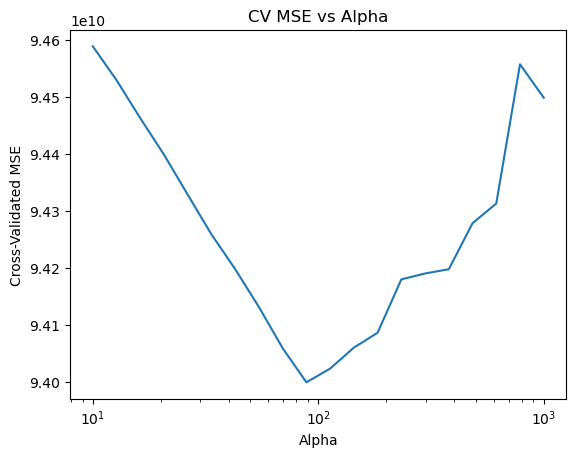

In [33]:
# part 4
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)
plt.figure()
plt.semilogx(lasso.alphas_, mean_mse)
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.410e+10, toler

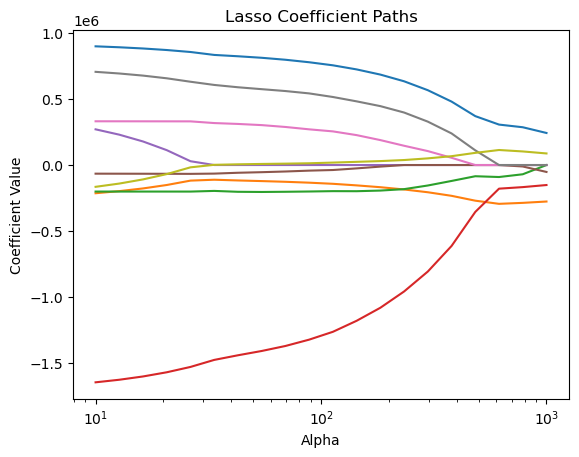

In [34]:
# part 5
from sklearn.linear_model import Lasso
coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_scaled, y)
    coefs.append(l.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficient Paths")
plt.show()

In [35]:
# part 6
num_zero = np.sum(lasso_coefs == 0)
total = len(lasso_coefs)
num_zero, total, num_zero / total

(1, 9, 0.1111111111111111)

3 features were selected: age^2, mileage_run^3, and mileage_run^2 age. This is about 33 percent of the data.

In [36]:
# part 7
comparison = pd.DataFrame({'Linear': coeffs, 'Lasso': lasso_coefs})
comparison

,Linear,Lasso
Mileage_Run,9.117748e+05,7.789506e+05
Age,-2.481722e+05,-1.337436e+05
Mileage_Run^2,-2.072926e+05,-2.006015e+05
Mileage_Run Age,-1.671212e+06,-1.323307e+06
Age^2,3.505507e+05,0.000000e+00
Mileage_Run^3,-6.514490e+04,-4.246012e+04
Mileage_Run^2 Age,3.388195e+05,2.705049e+05
Mileage_Run Age^2,7.167816e+05,5.428505e+05
Age^3,-2.100379e+05,1.334198e+04


Most of the coefficients shrink from linear to lasso and one became 0 which is age^2

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [37]:
df = pd.read_csv('datasets/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [38]:
# part 1
X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)
cont_feature_names = poly_cont.get_feature_names_out(X_cont.columns)

In [39]:
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)
X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

In [40]:
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)
cat_feature_names = poly_cat.get_feature_names_out(X_cat.columns)

X = np.hstack([X_cont_scaled, X_cat_inter])
y = df['DEATH_EVENT'].values
feature_names = list(cont_feature_names) + list(cat_feature_names)

In [41]:
# part 2
lr = LinearRegression()
lr.fit(X, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)
lr_coefs

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

Yes there are some parts that seem counterintuitive because there are a lot of related terms. The higher powered coefficients and terms dont accurately represent relationships individually. 

In [42]:
# part 3
alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=0)
lasso.fit(X, y)
best_alpha = lasso.alpha_
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
best_alpha

0.005736152510448681

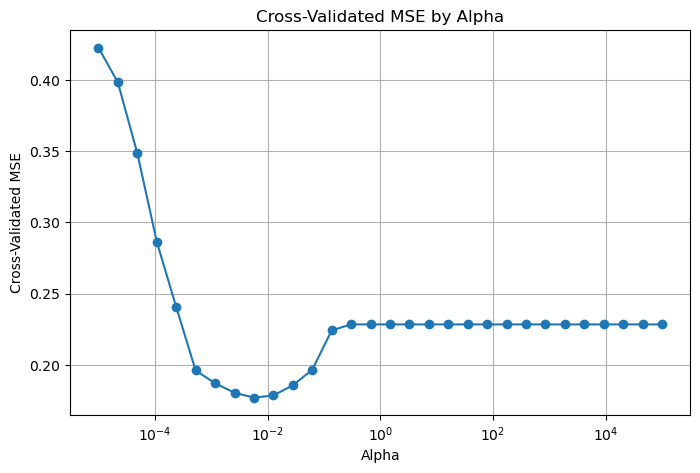

In [43]:
# part 4
mean_mse = np.mean(lasso.mse_path_, axis=1)
plt.figure(figsize=(8,5))
plt.semilogx(lasso.alphas_, mean_mse, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validated MSE by Alpha")
plt.grid(True)
plt.show()

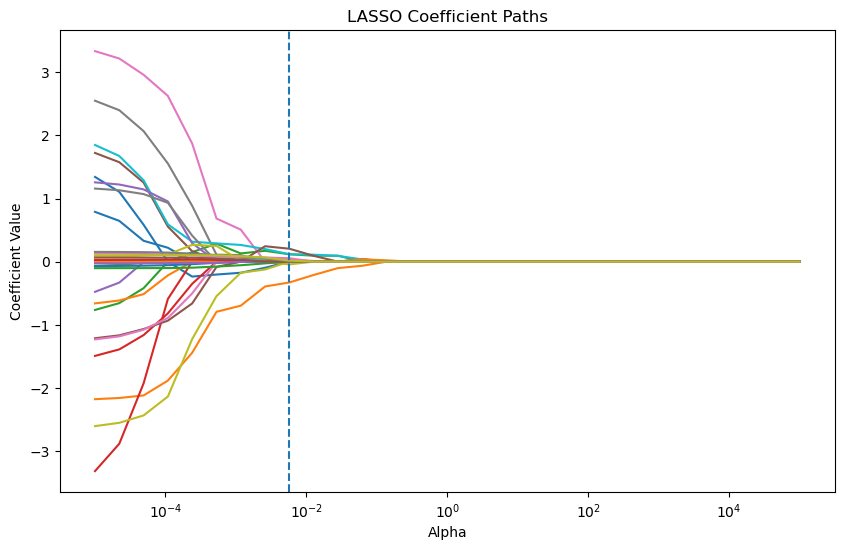

In [44]:
# part 5
coefs = []
for a in alphas:
    lasso_path_model = Lasso(alpha=a, max_iter=100000)
    lasso_path_model.fit(X, y)
    coefs.append(lasso_path_model.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.axvline(best_alpha, linestyle='--')
plt.show()

In [45]:
# part 6
selected_features = lasso_coefs[lasso_coefs != 0]
removed_features = lasso_coefs[lasso_coefs == 0]
num_selected = (lasso_coefs != 0).sum()
num_zero = (lasso_coefs == 0).sum()
prop_zero = num_zero / len(lasso_coefs)

comparison = pd.DataFrame({'Linear Regression': lr_coefs,'LASSO': lasso_coefs})
selected_features
removed_features.index.tolist()
num_selected, num_zero, prop_zero
comparison

,Linear Regression,LASSO
age,1.539156,-0.000000
ejection_fraction,-2.192494,-0.329656
serum_creatinine,-0.853588,0.116875
age^2,-3.678654,0.000000
age ejection_fraction,-0.600918,-0.000000
age serum_creatinine,1.841563,0.000000
ejection_fraction^2,3.430976,0.000000
ejection_fraction serum_creatinine,2.673394,0.000000
serum_creatinine^2,-2.647041,-0.000000
age^3,1.993135,0.117992


ejection_fraction, ejection_fraction^3, age^3, serum_creatinine, diabetes high_blood_pressure, serum_creatinine^3, ejection_fraction^2 serum_creatinine, high_blood_pressure smoking, anaemia, high_blood_pressure, diabetes smoking, and diabetes are all featuers that were selected. 17 out of the 29 features were set to zero which is a proportion of 58.6%. The lass is simpler compared to the linear regression and most of the coefficient shrink in size. Also, some coefficients change signs: ejection_fraction^3, serum_creatinine, serum_creatinine^3, ejection_fraction^2 serum_creatinine, high_blood_pressure, and diabetes. the lasso model makes more sense since it is simpler and understands which feature relationships are necessary for the model to perform. The bias that lasso adds to the model ends up minimizng the variance which in turn makes the model therefore validating the bias-variance tradeoff.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

#### part 1 and 2

![Q4 Work](IMG_3371.png)

##### part 3
As $\alpha$ increases, b1 gets smaller.

#### part 4

The challenge wre run into is that abs isnt differentiable when b1 equals 0. It is optimal to set b1 to 0 is when the relationship between the input and output have a weak correlation.